In [1]:
import xarray as xr

file_path = "../data/raw/SSS/SSS.nc"

ds = xr.open_dataset(file_path)

print(ds)

<xarray.Dataset> Size: 464MB
Dimensions:    (time: 604, depth: 1, latitude: 200, longitude: 480)
Coordinates:
  * time       (time) datetime64[ns] 5kB 2025-01-01 2025-01-02 ... 2026-08-27
  * depth      (depth) float32 4B 0.0
  * latitude   (latitude) float32 800B 5.062 5.188 5.312 ... 29.69 29.81 29.94
  * longitude  (longitude) float32 2kB 45.06 45.19 45.31 ... 104.7 104.8 104.9
Data variables:
    sos        (time, depth, latitude, longitude) float64 464MB ...
Attributes: (12/17)
    Conventions:               CF-1.7
    Scaling_Equation:          (scale_factor*data) + add_offset
    contact:                   servicedesk.cmems@mercator-ocean.eu
    creation_date:             Mon 29 Jun 2026 08:39:26
    easternmost_longitude:     179.9375
    grid_resolution:           0.125 degrees
    ...                        ...
    references:                Buongiorno Nardelli, B., R. Droghei, and R. Sa...
    software_version:          SSS/SSD HR Processor v1.0
    southernmost_latitude:   

In [2]:
print(ds.dims)
print(ds.coords)
print(ds.data_vars)

FrozenMappingWarningOnValuesAccess({'time': 604, 'depth': 1, 'latitude': 200, 'longitude': 480})
Coordinates:
  * time       (time) datetime64[ns] 5kB 2025-01-01 2025-01-02 ... 2026-08-27
  * depth      (depth) float32 4B 0.0
  * latitude   (latitude) float32 800B 5.062 5.188 5.312 ... 29.69 29.81 29.94
  * longitude  (longitude) float32 2kB 45.06 45.19 45.31 ... 104.7 104.8 104.9
Data variables:
    sos      (time, depth, latitude, longitude) float64 464MB ...


In [3]:
sss = ds["sos"]

print(sss.attrs)

{'long_name': 'sea surface salinity', 'standard_name': 'sea_surface_salinity', 'units': '.001'}


In [4]:
print(sss.encoding)

{'dtype': dtype('float32'), 'zlib': False, 'szip': False, 'zstd': False, 'bzip2': False, 'blosc': False, 'shuffle': False, 'complevel': 0, 'fletcher32': False, 'contiguous': True, 'chunksizes': None, 'source': 'c:\\OceanF\\data\\raw\\SSS\\SSS.nc', 'original_shape': (604, 1, 200, 480), '_FillValue': np.float32(-32767.0), 'scale_factor': np.float64(1.0), 'add_offset': np.float64(0.0)}


In [5]:
print("Data type:", sss.dtype)

Data type: float64


In [6]:
print("Minimum:", float(sss.min()))
print("Maximum:", float(sss.max()))
print("Mean:", float(sss.mean()))

Minimum: 26.181299209594727
Maximum: 40.0
Mean: 34.5927788334429


In [7]:
print("Missing values:", int(sss.isnull().sum()))

Missing values: 29365272


In [8]:
sss = ds["sos"]

print("========== ATTRIBUTES ==========")
print(sss.attrs)

print("\n========== ENCODING ==========")
print(sss.encoding)

print("\n========== BASIC INFO ==========")
print("Data type:", sss.dtype)
print("Minimum:", float(sss.min()))
print("Maximum:", float(sss.max()))
print("Mean:", float(sss.mean()))
print("Missing values:", int(sss.isnull().sum()))

========== ATTRIBUTES ==========
{'long_name': 'sea surface salinity', 'standard_name': 'sea_surface_salinity', 'units': '.001'}

========== ENCODING ==========
{'dtype': dtype('float32'), 'zlib': False, 'szip': False, 'zstd': False, 'bzip2': False, 'blosc': False, 'shuffle': False, 'complevel': 0, 'fletcher32': False, 'contiguous': True, 'chunksizes': None, 'source': 'c:\\OceanF\\data\\raw\\SSS\\SSS.nc', 'original_shape': (604, 1, 200, 480), '_FillValue': np.float32(-32767.0), 'scale_factor': np.float64(1.0), 'add_offset': np.float64(0.0)}

========== BASIC INFO ==========
Data type: float64
Minimum: 26.181299209594727
Maximum: 40.0
Mean: 34.5927788334429
Missing values: 29365272


In [9]:
print("Time start:", ds.time.values[0])
print("Time end:", ds.time.values[-1])

print("Depth:", ds.depth.values)

print("Latitude:",
      float(ds.latitude.min()),
      "to",
      float(ds.latitude.max()))

print("Longitude:",
      float(ds.longitude.min()),
      "to",
      float(ds.longitude.max()))

print("Dataset attributes:")
print(ds.attrs)

Time start: 2025-01-01T00:00:00.000000000
Time end: 2026-08-27T00:00:00.000000000
Depth: [0.]
Latitude: 5.0625 to 29.9375
Longitude: 45.0625 to 104.9375
Dataset attributes:
{'Conventions': 'CF-1.7', 'Scaling_Equation': '(scale_factor*data) + add_offset', 'contact': 'servicedesk.cmems@mercator-ocean.eu', 'creation_date': 'Mon 29 Jun 2026 08:39:26', 'easternmost_longitude': '179.9375', 'grid_resolution': '0.125 degrees', 'institution': 'CNR', 'license': 'free registration at Copernicus Marine Service (http://marine.copernicus.eu/web/56-user-registration-form.php)', 'netcdf_version_id': '4.9.2 of Dec 10 2023 17:23:27 ', 'northernmost_latitude': '89.9375', 'product_version': '1.0', 'references': 'Buongiorno Nardelli, B., R. Droghei, and R. Santoleri (2016), Multi-dimensional interpolation of SMOS sea surface salinity with surface temperature and in situ salinity data, Remote Sens. Environ., doi:10.1016/j.rse.2015.12.052.;Sammartino, M., Aronica, S., Santoleri, S., and B. Buongiorno Nardell

In [10]:
print("Values exactly 40:",
      int((sss == 40.0).sum().values))

Values exactly 40: 1540


In [11]:
missing_percentage = (
    sss.isnull().sum() / sss.size
) * 100

print("Total values:", sss.size)
print("Missing values:", int(sss.isnull().sum()))
print("Missing percentage:", float(missing_percentage), "%")

Total values: 57984000
Missing values: 29365272
Missing percentage: 50.64375 %


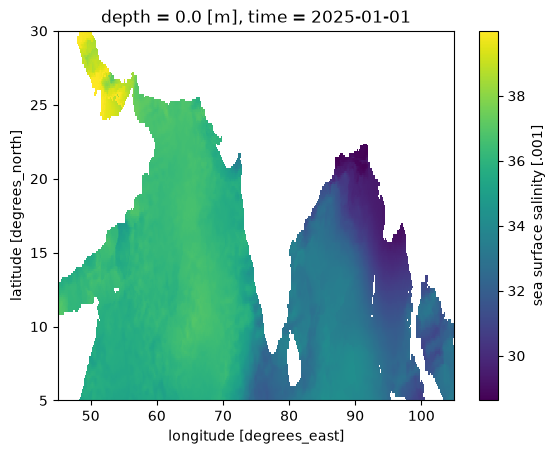

In [12]:
sss_day1 = sss.isel(time=0, depth=0)

sss_day1.plot()

import matplotlib.pyplot as plt
plt.show()

In [13]:
import xarray as xr

processed_file = "../data/processed/SSS/SSS_processed.nc"

ds_sss = xr.open_dataset(processed_file)

print(ds_sss)

<xarray.Dataset> Size: 232MB
Dimensions:    (time: 604, latitude: 200, longitude: 480)
Coordinates:
  * time       (time) datetime64[ns] 5kB 2025-01-01 2025-01-02 ... 2026-08-27
  * latitude   (latitude) float32 800B 5.062 5.188 5.312 ... 29.69 29.81 29.94
  * longitude  (longitude) float32 2kB 45.06 45.19 45.31 ... 104.7 104.8 104.9
Data variables:
    sss        (time, latitude, longitude) float32 232MB ...
Attributes: (12/19)
    Conventions:               CF-1.7
    Scaling_Equation:          (scale_factor*data) + add_offset
    contact:                   servicedesk.cmems@mercator-ocean.eu
    creation_date:             Mon 29 Jun 2026 08:39:26
    easternmost_longitude:     179.9375
    grid_resolution:           0.125 degrees
    ...                        ...
    southernmost_latitude:     -89.9375
    title:                     Global Analysed Sea Surface Salinity and Density
    westernmost_longitude:     -179.9375
    copernicusmarine_version:  2.4.1
    time_coverage_start:

In [14]:
sss_processed = ds_sss["sss"]

print(sss_processed.attrs)

print("Minimum:", float(sss_processed.min()))
print("Maximum:", float(sss_processed.max()))
print("Mean:", float(sss_processed.mean()))

print("Missing:", int(sss_processed.isnull().sum()))

{'long_name': 'sea surface salinity', 'standard_name': 'sea_surface_salinity', 'units': '.001', 'description': 'Sea surface salinity at 0 m depth'}
Minimum: 26.181299209594727
Maximum: 40.0
Mean: 34.592777252197266
Missing: 29365272


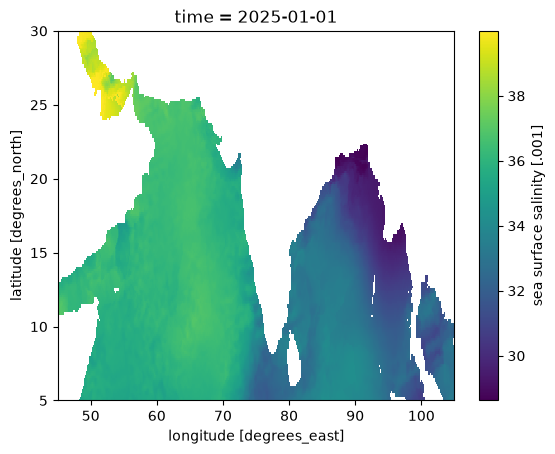

In [15]:
sss_processed.isel(time=0).plot()

import matplotlib.pyplot as plt
plt.show()